In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpi4py import MPI
from dolfinx import mesh, fem
from visualization_fct import *
from my_functions import create_quad_domain
import pickle

In [7]:
# Define geometry
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
slope = (P1[1]-P0[1])/(P1[0]-P0[0])

nx = 60
nz = 30
T_end = 720 # end time [h]
#filename = "../solutions/heterogeneous_" + str(T_end) + "h_nx" + str(nx) + "_nz" + str(nz) + ".pkl"
filename = "../../Masterarbeit/solutions/iso_test_Dirichlet.pkl"

In [8]:
# Load solution
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)
# Create domain
domain = create_quad_domain(MPI.COMM_WORLD, nx, nz, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)
V = fem.functionspace(domain, ("CG", 1))
Q = fem.functionspace(domain, ("DG", 0))
h_w = fem.Function(V)
Ks = fem.Function(Q)
N = fem.Function(Q)
alpha = fem.Function(Q)
theta_r = fem.Function(Q)
theta_s = fem.Function(Q)

In [9]:
t_obs = 3 # observation time [h]
h_w.x.array[:] = np.array(data_Annika["h_w"][t_obs])
Ks.x.array[:] = np.array(data_Annika["Ks"])
alpha.x.array[:] = np.array(data_Annika["alpha"])
N.x.array[:] = np.array(data_Annika["N"])
theta_r.x.array[:] = np.array(data_Annika["theta_r"])
theta_s.x.array[:] = np.array(data_Annika["theta_s"])

# Evaluate solution
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, h_w, domain).reshape((nz,nx))
alpha_eval = eval_fct_on_grid(grid, alpha, domain).reshape((nz,nx))
N_eval = eval_fct_on_grid(grid, N, domain).reshape((nz,nx))
theta_r_eval = eval_fct_on_grid(grid, theta_r, domain).reshape((nz,nx))
theta_s_eval = eval_fct_on_grid(grid, theta_s, domain).reshape((nz,nx))
h_tot = pressure_head + grid[:,1].reshape((nz, nx))
h_c = pressure_head * (pressure_head <= 0)
def S_e1(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = theta_r_eval + (theta_s_eval - theta_r_eval)*S_e1(h_c.flatten(), alpha_eval.flatten(), N_eval.flatten()).reshape((nz,nx))

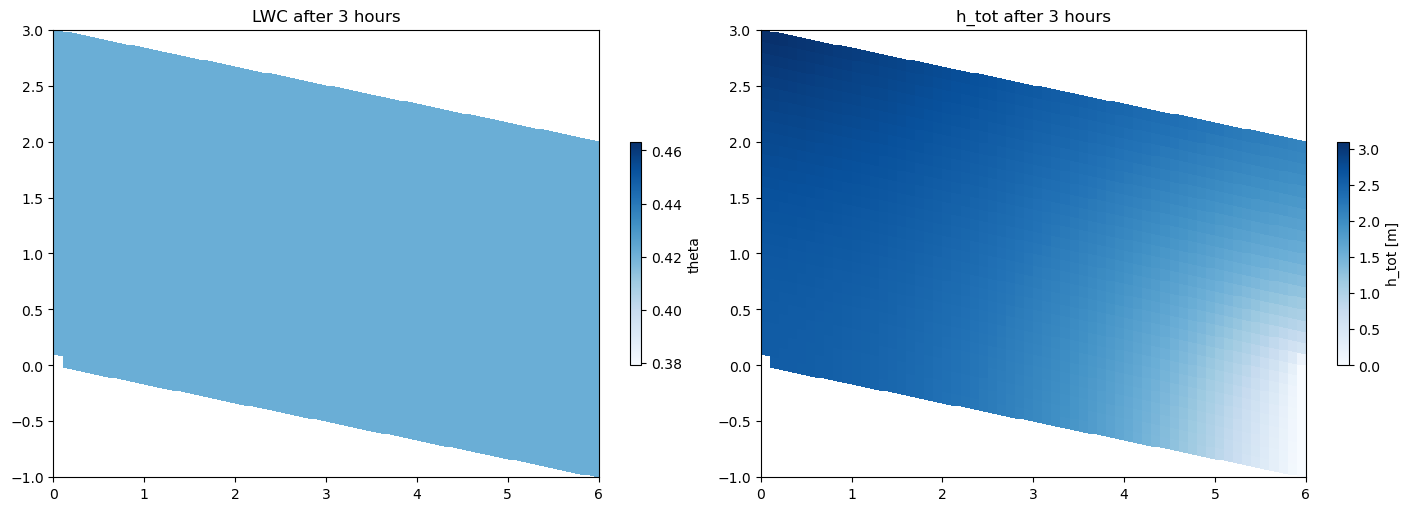

In [12]:
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues")
ax[0].set_title(f"LWC after {t_obs} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after {t_obs} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [11]:
pressure_head

array([[       nan, 2.58355238, 2.59782476, ..., 1.14781284, 1.06686438,
        1.        ],
       [2.46529701, 2.48118304, 2.49560963, ..., 1.05933396, 0.97566136,
        0.89655172],
       [2.36454884, 2.38028051, 2.39470729, ..., 0.96896216, 0.87986095,
        0.79310345],
       ...,
       [0.21967544, 0.22898884, 0.23569597, ..., 0.20889507, 0.21309369,
        0.22026391],
       [0.15503415, 0.16276267, 0.1668543 , ..., 0.15485359, 0.15739812,
        0.16455515],
       [0.1       , 0.1       , 0.1       , ..., 0.1       , 0.1       ,
        0.1       ]], shape=(30, 60))

In [6]:
# open pickle file and load
with open("Test_Annika_heterogen.pkl", "rb") as f:
    data = pickle.load(f)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [7]:
anne_x = data["X_plot"]
anne_z = data["Z_plot"]
anne_theta = data["theta_l_total"][t_obs]
anne_h_tot = data["h_total"][t_obs]
anne_h_c = data["h_c_total"][t_obs]

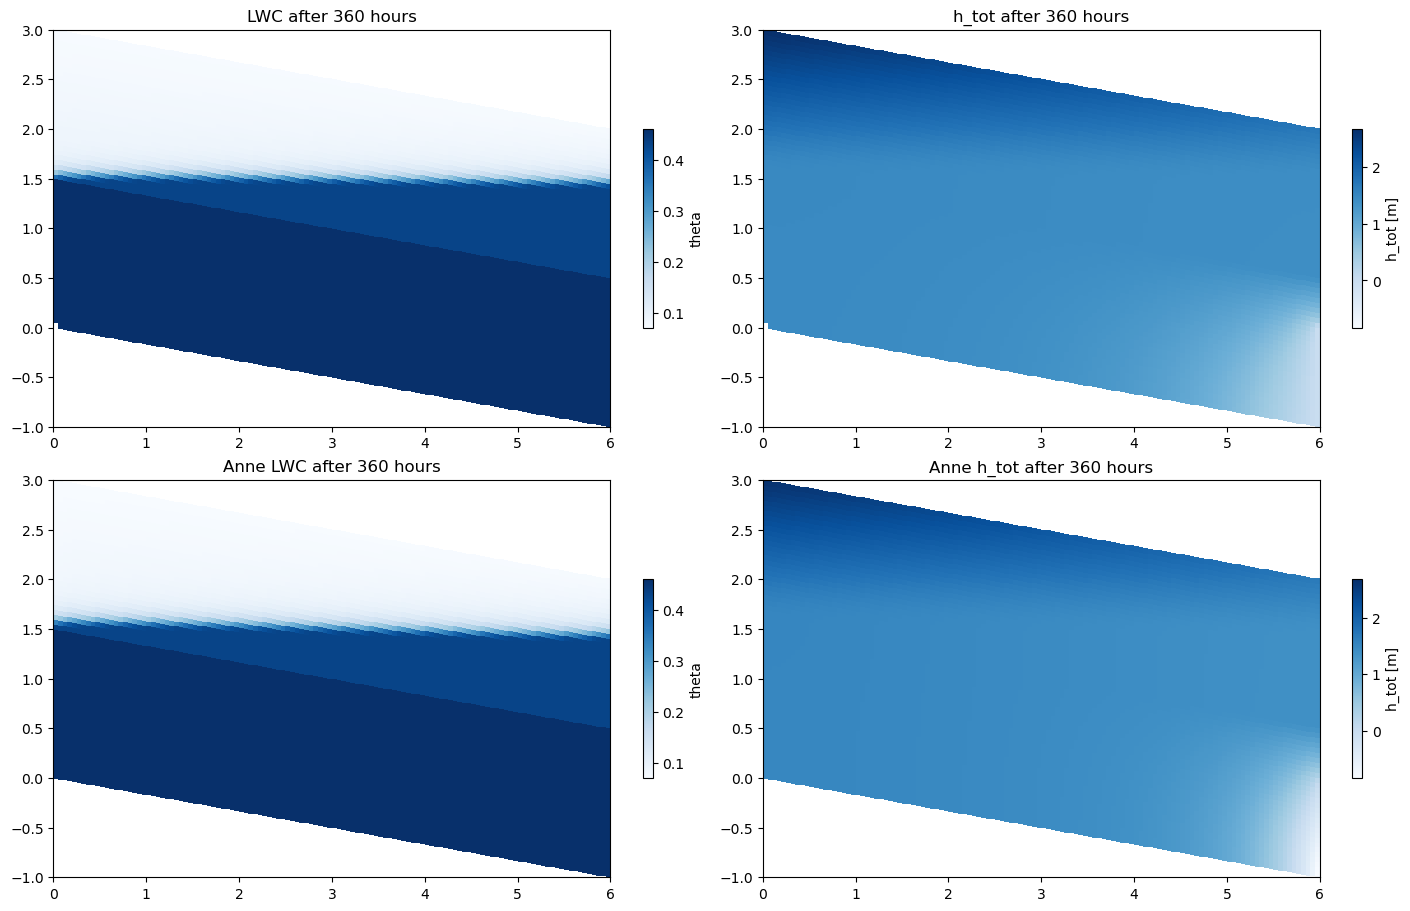

In [9]:
vmin_theta = np.min([np.nanmin(theta_tot), np.nanmin(anne_theta)])
vmin_h = np.min([np.nanmin(h_tot), np.nanmin(anne_h_tot)])

vmax_theta = np.max([np.nanmax(theta_tot), np.nanmax(anne_theta)])
vmax_h = np.max([np.nanmax(h_tot), np.nanmax(anne_h_tot)])

fig, ax = plt.subplots(2,2, layout="constrained", figsize=(14,9))
pmsh1 = ax[0, 0].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues", vmin=vmin_theta, vmax=vmax_theta)
ax[0, 0].set_title(f"LWC after {t_obs} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[0, 1].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues", vmin=vmin_h, vmax=vmax_h)
ax[0, 1].set_title(f"h_tot after {t_obs} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[0, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

pmsh11 = ax[1, 0].pcolormesh(anne_x, anne_z, anne_theta, cmap="Blues", shading="flat", vmin=vmin_theta, vmax=vmax_theta)
ax[1, 0].set_title(f"Anne LWC after {t_obs} hours")
cbar1 = fig.colorbar(pmsh11, ax=ax[1, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh12 = ax[1, 1].pcolormesh(anne_x, anne_z, anne_h_tot, cmap="Blues", shading="flat", vmin=vmin_h, vmax=vmax_h)
ax[1, 1].set_title(f"Anne h_tot after {t_obs} hours")
cbar2 = fig.colorbar(pmsh12, ax=ax[1, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

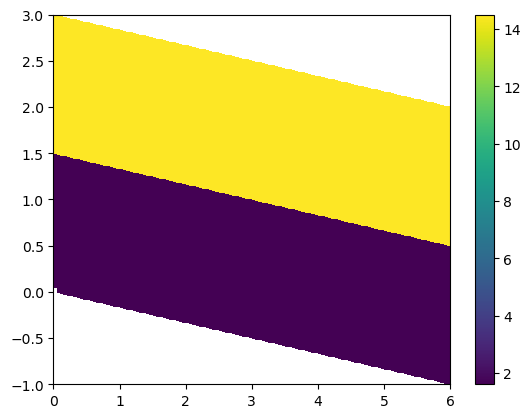

In [37]:
plt.pcolormesh(x_plot, z_plot, alpha_eval)
plt.colorbar()